# Stochastic random walk kernels

## Imports

In [1]:
import numpy as np
import networkx as nx
import scipy.linalg as la
from scipy.sparse.linalg import cg, LinearOperator
import math
import random as rnd
import time
import scipy
import matplotlib.pyplot as plt

## Some functions

In [2]:
def graph_generator(n, kind="er", seed=None):
    """
    er for Erdos-Renyi;
    ba for Barabasi-Albert;
    ws for Watts-Strogtz (small-world);
    sbm for Stochastic Block Model
    """
    
    if kind == "er":
        #Erdos-Renyi
        #p = 2.0/n gives us a moderately sparse graph:
        #E[deg] = (n - 1) * p = 2
        return nx.erdos_renyi_graph(n=n, p=float(2.0/n), seed=seed)
    
    if kind == "ba":
        #Barabasi-Albert (preferential attachment)
        # Each new node connects to m = max(1, n // 20) existing nodes.
        # This yields a scale-free graph with hubs.
        return nx.barabasi_albert_graph(n=n, m=max(1, n // 20), seed=seed)
    
    if kind == "ws":
        #Watts-Strogtz (small-world)
        # Start with a ring where each node connects to k neighbors, then rewire edges with p = 0.1.
        # This keeps high clustering while creating short average paths.
        k = int(max(2, (n // 10) | 1))
        p = float(0.1)
        return nx.watts_strogatz_graph(n=n, k=k, p=p, seed=seed)

    if kind == "sbm":
        # Stochastic Block Model with 2 groups.
        # Connect nodes within the same group with p_in = 0.15,
        # and across groups with p_out = 0.02 (weaker connections).
        sizes = [n//2, n - n//2]
        p_in, p_out = float(0.15), float(0.02)
        P = [
            [p_in,  p_out],
            [p_out, p_in]
        ]
        return nx.stochastic_block_model(sizes, P, seed=seed)
    
    raise ValueError(f"unknown kind: {kind}")

In [3]:
def graph_generator_labeled(n, kind="er", n_labels=3, seed=None):
    g = graph_generator(n, kind=kind, seed=seed)
    rng = np.random.default_rng(seed)
    for u, v in g.edges():
        g[u][v]["label"] = int(rng.integers(0, n_labels))
    return g

In [4]:
def normalized_adj_matrix(graph):
    A = nx.to_numpy_array(graph, dtype=float)
    deg = A.sum(axis=1)

    P = np.zeros_like(A, dtype=float)
    for i in range(A.shape[0]):
        if deg[i] > 0:
            P[i] = A[i] / deg[i]
        else:
            P[i, i] = 1.0

    return P

In [5]:
def normalized_adj_matrix_labeled(graph):
    nodes = list(graph.nodes())
    n = len(nodes)
    idx = {u: i for i, u in enumerate(nodes)}
    A_labels = {}
    deg = np.zeros(n, dtype=float)

    for u, v, data in graph.edges(data=True):
        i, j = idx[u], idx[v]
        lab = int(data["label"])
        if lab not in A_labels:
            A_labels[lab] = np.zeros((n, n), dtype=float)
        A_labels[lab][i, j] = 1.0
        A_labels[lab][j, i] = 1.0
        deg[i] += 1.0
        deg[j] += 1.0

    P_labels = {}
    for lab, A in A_labels.items():
        P = np.zeros_like(A)
        for i in range(n):
            if deg[i] > 0:
                P[i, :] = A[i, :] / deg[i]
        P_labels[lab] = P

    return P_labels

In [6]:
def uniform_dist(n):
    return np.ones(n, dtype=float) / n

def random_dist(n):
    x = np.random.random(n)
    return x / x.sum()

In [7]:
def mu_func_gen(kind="exp", lmbd=0.1):
    if kind == "exp":
        def mu(k):
            return (lmbd ** k) / math.factorial(k)
        return mu
    if kind == "geom":
        def mu(k):
            return lmbd ** k
        return mu
    raise ValueError(f"unknown kind: {kind}")

## Brute Force computations

#### Unlabeled

In [8]:
def random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func, kind="general", max_iter=30):
    n1, n2 = len(v1), len(v2)
    W = np.kron(P1, P2)
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)
    
    if kind == "exp":
        lmbd = mu_func(1)
        S = la.expm(lmbd * W)
        
    elif kind == "geom":
        lmbd = mu_func(1)
        I = np.eye(W.shape[0], dtype=float)
        S = np.linalg.inv(I - lmbd * W)
        
    else:
        Wk = np.eye(W.shape[0], dtype=float)
        S = mu_func(0) * Wk
        for k in range(1, max_iter + 1):
            Wk = Wk @ W
            S += mu_func(k) * Wk
            
    return float(v @ (S @ w))

#### Labeled

In [9]:
def random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, kind="general", max_iter=30):
    n1, n2 = len(v1), len(v2)
    W = np.zeros((n1 * n2, n1 * n2), dtype=float)
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)

    for label in set(P1_labeled.keys()) & set(P2_labeled.keys()):
        W += np.kron(P1_labeled[label], P2_labeled[label])
        
    if kind == "exp":
        lmbd = mu_func(1)
        S = la.expm(lmbd * W)
        
    elif kind == "geom":
        lmbd = mu_func(1)
        I = np.eye(W.shape[0], dtype=float)
        S = np.linalg.inv(I - lmbd * W)
        
    else:
        Wk = np.eye(W.shape[0], dtype=float)
        S = mu_func(0) * Wk
        for k in range(1, max_iter + 1):
            Wk = Wk @ W
            S += mu_func(k) * Wk
            
    return float(v @ (S @ w))

## Existing Optimizations

Sylvester Equation, Fixed Point and Conjugate Gradient methods from Vishwanathan et al. 2010 are applied only for geometric kernel

### Sylvester Equation 

#### Unlabeled

In [10]:
def random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func):
    """
    geometric random-walk kernel via Schur-based Sylvester equation.
    """
    lmbd = mu_func(1)
    W0 = np.outer(w2, w1)
    V0 = np.outer(v2, v1)
    T2, U2 = la.schur(P2, output="complex")
    T1, U1 = la.schur(P1.T, output="complex")
    C = U2.conj().T @ W0 @ U1
    n2, n1 = C.shape
    Y = np.zeros((n2, n1), dtype=complex)

    for j in range(n1):
        rhs = C[:, j].copy()
        if j > 0:
            accum = np.zeros(n2, dtype=complex)
            for k in range(j):
                accum += Y[:, k] * T1[k, j]
            rhs += lmbd * (T2 @ accum)
        A = np.eye(n2, dtype=complex) - lmbd * T1[j, j] * T2
        Y[:, j] = np.linalg.solve(A, rhs)

    M = U2 @ Y @ U1.conj().T
    val = np.sum(V0 * M)

    return float(np.real_if_close(val))

#### Labeled

### Fixed Point Iteration

#### Unlabeled

In [11]:
def random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    n1, n2 = P1.shape[0], P2.shape[0]
    lmbd = mu_func(1)
    w0 = np.outer(w2, w1) # vec(w0) = w1 \otimes w2
    v0 = np.outer(v2, v1)
    x = w0.copy()

    for i in range(max_iter):
        x_new = w0 + lmbd * (P2 @ x @ P1.T)
        if np.linalg.norm(x_new - x, ord="fro") <= eps:
            x = x_new
            break
        x = x_new
        
    return float(np.sum(v0 * x))

#### Labeled

In [12]:
def random_walk_kernel_fixed_point_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    common_labels = set(P1_labeled.keys()) & set(P2_labeled.keys())
    w0 = np.outer(w2, w1)
    v0 = np.outer(v2, v1)
    x = w0.copy()
    lmbd = mu_func(1)

    for i in range(max_iter):
        x_new = w0.copy()
        for label in common_labels:
            x_new += lmbd * (P2_labeled[label] @ x @ P1_labeled[label].T)
        
        if np.linalg.norm(x_new - x, ord="fro") <= eps:
            x = x_new
            break
        
        x = x_new

    return float(np.sum(v0 * x))

### Conjugate gradient

#### Unlabeled

In [13]:
def random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    n1, n2 = P1.shape[0], P2.shape[0]
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)
    lmbd = mu_func(1)
    
    def matvec(x):
        X = x.reshape((n2, n1), order="F")
        Y = X - lmbd * (P2 @ X @ P1.T)
        return Y.reshape(-1, order="F")

    A = LinearOperator(shape=(n1 * n2, n1 * n2),matvec=matvec, dtype=float)
    x, info = cg(A, w, rtol=eps, maxiter=max_iter)
    return float(v @ x)

#### Labeled

In [ ]:
def random_walk_kernel_cg_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_func, eps=1e-30, max_iter=1000):
    common_labels = set(P1_labeled.keys()) & set(P2_labeled.keys())
    n1, n2 = len(v1),len(v2)
    v = np.kron(v1, v2)
    w = np.kron(w1, w2)
    lmbd = mu_func(1)

    def matvec(x):
        X = x.reshape((n2, n1), order="F")
        Y = X.copy()
        for label in common_labels:
            Y -= lmbd * (P1_labeled[label] @ X @ P2_labeled[label].T)
        return Y.reshape(-1, order="F")

    operator = LinearOperator(shape=(n1 * n2, n1 * n2), matvec=matvec, dtype=float)
    x, info = cg(operator, w, rtol=eps, maxiter=max_iter)
    return float(v @ x)

#### Unlabeled test

In [ ]:
n = 50
G1 = graph_generator(n, kind="er", seed=1)
G2 = graph_generator(n, kind="er", seed=2)

P1 = normalized_adj_matrix(G1)
P2 = normalized_adj_matrix(G2)

v1 = uniform_dist(n)
v2 = uniform_dist(n)
w1 = uniform_dist(n)
w2 = uniform_dist(n)

mu_exp = mu_func_gen("exp", lmbd=0.1)
mu_geom = mu_func_gen("geom", lmbd=0.1)

#exp
k_exp_exact = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_exp, kind="exp")
k_exp_trunc = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_exp, kind="general", max_iter=20)
print("exp exact :", k_exp_exact)
print("exp trunc :", k_exp_trunc)

#geom
k_geom_exact = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_geom, kind="geom")
k_geom_trunc = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_geom, kind="general", max_iter=20)

k_geom_sylv = random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_geom)
k_geom_fp = random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_geom)
k_geom_cg = random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_geom)

print("geom exact:", k_geom_exact)
print("geom trunc:", k_geom_trunc)
print("sylvester:", k_geom_sylv)
print("fixed point:", k_geom_fp)
print("cg:", k_geom_cg)

exp exact : 0.00044206836723025835
exp trunc : 0.00044206836723025835
geom exact: 0.00044444444444444555
geom trunc: 0.00044444444444444555
sylvester: 0.00044444444444444577
fixed point: 0.00044444444444444447
cg: 0.00044444444444444544


#### Labeled test

In [16]:
# Labeled
n = 50
n_labels = 3
G1 = graph_generator_labeled(n, kind="er", n_labels=n_labels, seed=1)
G2 = graph_generator_labeled(n, kind="er", n_labels=n_labels, seed=2)

P1_labeled = normalized_adj_matrix_labeled(G1)
P2_labeled = normalized_adj_matrix_labeled(G2)

v1 = uniform_dist(n)
v2 = uniform_dist(n)
w1 = uniform_dist(n)
w2 = uniform_dist(n)

mu_exp = mu_func_gen("exp", lmbd=0.1)
mu_geom = mu_func_gen("geom", lmbd=0.1)

k_exp_exact = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_exp, kind="exp")
k_exp_trunc = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_exp, kind="general", max_iter=20)
print("exp exact :", k_exp_exact)
print("exp trunc :", k_exp_trunc)

k_geom_exact = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom, kind="geom")
k_geom_trunc = random_walk_kernel_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom, kind="general", max_iter=20)
# k_geom_sylv = random_walk_kernel_sylvester_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)
k_geom_fixed_point = random_walk_kernel_fixed_point_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)
k_geom_cg = random_walk_kernel_cg_labeled(P1_labeled, P2_labeled, v1, v2, w1, w2, mu_geom)

print("geom exact:", k_geom_exact)
print("geom trunc:", k_geom_trunc)
print("fixed point:", k_geom_fixed_point)
print("cg:", k_geom_cg)

exp exact : 0.00041025820688906105
exp trunc : 0.00041025820688906105
geom exact: 0.00041050786806759795
geom trunc: 0.00041050786806759795
fixed point: 0.00041050786806759844
cg: 0.00041050786806759795


### Graph Voyagers 

from Choromanski et al. 2025. Changes were made to tailor it to make algorithm more correct and robust, tailor it for geometric kernel

In [17]:
SIGMA = 0.1
LAMBDA_COEFF = 0.1
P_HALT = 0.2
NB_RANDOM_WALKS = 1000
RANDOM_SEED = 180
BIG_NUMBER = 10000

np.random.seed(RANDOM_SEED)
t_variables = np.random.uniform(size=(2 * BIG_NUMBER, 2 * BIG_NUMBER))
g_variables = np.where(np.random.normal(size=(2 * BIG_NUMBER, 2 * BIG_NUMBER)) > 0.0, 1.0, -1.0,)

def adj_matrix_to_lists(P):
    adj_lists = []
    weight_lists = []
    for i in range(P.shape[0]):
        neigh = np.where(P[i] > 0.0)[0].tolist()
        weights = P[i, neigh].tolist()
        adj_lists.append(neigh)
        weight_lists.append(weights)
    return adj_lists, weight_lists

def f_func_diffusion(i, lambda_coeff):
    # exponential kernel modulation
    return lambda_coeff ** i / (2 ** i * scipy.special.factorial(i))

def f_func_geometric(i, lambda_coeff):
    # geometric kernel modulation
    return lambda_coeff ** i

def create_pq_vectors(adj_lists, weight_lists, anchor_points_dict, p_halt, nb_random_walks, f, is_left, base_nb_walk_index,):
    n = len(adj_lists)
    s_matrix = np.zeros((nb_random_walks, len(anchor_points_dict), n))

    for w in range(nb_random_walks):
        for k in range(n):
            load = 1.0
            step_counter = 0
            current_vertex = k
            x_index = is_left * BIG_NUMBER + step_counter
            y_index = is_left * BIG_NUMBER + w + base_nb_walk_index
            
            if current_vertex in anchor_points_dict:
                add_term = load * np.sqrt(f(step_counter))
                add_term *= g_variables[x_index][y_index]
                s_matrix[w, anchor_points_dict[current_vertex], k] += add_term

            if adj_lists[current_vertex] == []:
                continue

            while t_variables[x_index][y_index] > p_halt:
                if step_counter >= BIG_NUMBER - 1:
                    break
                rnd_index = int(rnd.uniform(0, 1) * len(adj_lists[current_vertex]))
                p_uv = weight_lists[current_vertex][rnd_index]
                load *= p_uv
                load *= 1.0 / np.sqrt(1.0 - p_halt)
                step_counter += 1
                current_vertex = adj_lists[current_vertex][rnd_index]
                x_index = is_left * BIG_NUMBER + step_counter
                y_index = is_left * BIG_NUMBER + w + base_nb_walk_index

                if current_vertex in anchor_points_dict:
                    add_term = load * np.sqrt(f(step_counter))
                    add_term *= g_variables[x_index][y_index]
                    s_matrix[w, anchor_points_dict[current_vertex], k] += add_term

                if adj_lists[current_vertex] == []:
                    break

    return s_matrix


def approximate_graph_kernel_value(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, base_nb_walk_index=0, kind="exponential", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    P1_adj_lists, P1_weight_lists = adj_matrix_to_lists(P1)
    P2_adj_lists, P2_weight_lists = adj_matrix_to_lists(P2)

    n1 = len(P1_adj_lists)
    n2 = len(P2_adj_lists)

    nb_anc1 = max(1, int(anchor_fraction * n1))
    nb_anc2 = max(1, int(anchor_fraction * n2))

    anc1 = np.random.choice(np.arange(n1), size=nb_anc1, replace=False)
    anc2 = np.random.choice(np.arange(n2), size=nb_anc2, replace=False)
    anc1 = np.sort(anc1)
    anc2 = np.sort(anc2)

    anc1_dict = dict(zip(anc1, np.arange(nb_anc1)))
    anc2_dict = dict(zip(anc2, np.arange(nb_anc2)))

    if kind == "exponential":
        f_function = lambda i: f_func_diffusion(i, lambda_coeff)
    elif kind == "geometric":
        f_function = lambda i: f_func_geometric(i, lambda_coeff)
    else:
        raise ValueError("kind must be 'exponential' or 'geometric'")

    p1 = create_pq_vectors(P1_adj_lists, P1_weight_lists, anc1_dict, p_halt, nb_random_walks, f_function, 0, base_nb_walk_index)
    p2 = create_pq_vectors(P2_adj_lists, P2_weight_lists, anc2_dict, p_halt, nb_random_walks, f_function, 0, base_nb_walk_index)
    
    q1 = create_pq_vectors(P1_adj_lists, P1_weight_lists, anc1_dict, p_halt, nb_random_walks, f_function, 1, base_nb_walk_index)
    q2 = create_pq_vectors(P2_adj_lists, P2_weight_lists, anc2_dict, p_halt, nb_random_walks, f_function, 1, base_nb_walk_index)
    
    P1_lat = np.einsum("br,br->br", np.einsum("brN,N->br", p1, v1), np.einsum("brN,N->br", q1, w1))
    P2_lat = np.einsum("br,br->br", np.einsum("brN,N->br", p2, v2), np.einsum("brN,N->br", q2, w2))
    
    final_batch = np.einsum("bx,by->bxy", P1_lat, P2_lat)
    return (1.0 / nb_random_walks) * np.sum(final_batch)


def approximate_graph_kernel_value_with_blocks(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, kind="exponential",
    lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS, block_size=NB_RANDOM_WALKS):
    approx_val = 0.0
    if nb_random_walks % block_size != 0:
        raise ValueError("nb_random_walks must be divisible by block_size.")
    
    for i in range(nb_random_walks // block_size):
        approx_val += approximate_graph_kernel_value(P1, P2, v1, v2, w1, w2,
            anchor_fraction=anchor_fraction,
            base_nb_walk_index=i * block_size,
            kind=kind,
            lambda_coeff=lambda_coeff,
            p_halt=p_halt,
            nb_random_walks=block_size,
        )

    return approx_val * (block_size / nb_random_walks)

In [18]:
N = 30
lmbd = 0.01
nb_random_walks = 1000
block_size = 1000

G1 = graph_generator(N, kind="er", seed=1)
G2 = graph_generator(N, kind="er", seed=2)

P1 = normalized_adj_matrix(G1)
P2 = normalized_adj_matrix(G2)

v1 = uniform_dist(N)
v2 = uniform_dist(N)
w1 = uniform_dist(N)
w2 = uniform_dist(N)

mu_exp = mu_func_gen("exp", lmbd=lmbd)
mu_geom = mu_func_gen("geom", lmbd=lmbd)

t0 = time.perf_counter()
exact_exp = random_walk_kernel(
    P1, P2, v1, v2, w1, w2,
    mu_func=mu_exp,
    kind="exp",
)
t1 = time.perf_counter()

np.random.seed(RANDOM_SEED)
t2 = time.perf_counter()
approx_exp = approximate_graph_kernel_value_with_blocks(
    P1, P2, v1, v2, w1, w2,
    anchor_fraction=1.0,
    kind="exponential",
    lambda_coeff=lmbd,
    p_halt=P_HALT,
    nb_random_walks=nb_random_walks,
    block_size=block_size,
)
t3 = time.perf_counter()

abs_err_exp = abs(exact_exp - approx_exp)
rel_err_exp = abs_err_exp / (abs(exact_exp))

print("exp kernel")
print(f"n={N}, lmbd={lmbd}, n_walks={nb_random_walks}, p_halt={P_HALT}")
print(f"exact  : {exact_exp}  time={t1 - t0}s")
print(f"approx : {approx_exp}  time={t3 - t2}s")
print(f"abs err: {abs_err_exp}")
print(f"rel err: {rel_err_exp}")

t4 = time.perf_counter()
exact_geom = random_walk_kernel(
    P1, P2, v1, v2, w1, w2,
    mu_func=mu_geom,
    kind="geom",
)
t5 = time.perf_counter()

np.random.seed(RANDOM_SEED)
t6 = time.perf_counter()
approx_geom = approximate_graph_kernel_value_with_blocks(
    P1, P2, v1, v2, w1, w2,
    anchor_fraction=1.0,
    kind="geometric",
    lambda_coeff=lmbd,
    p_halt=P_HALT,
    nb_random_walks=nb_random_walks,
    block_size=block_size,
)
t7 = time.perf_counter()

abs_err_geom = abs(exact_geom - approx_geom)
rel_err_geom = abs_err_geom / (abs(exact_geom))

print("geom kernel")
print(f"n={N}, lmbd={lmbd}, n_walks={nb_random_walks}, p_halt={P_HALT}")
print(f"exact  : {exact_geom}  time={t5 - t4}s")
print(f"approx : {approx_geom}  time={t7 - t6}s")
print(f"abs err: {abs_err_geom}")
print(f"rel err: {rel_err_geom}")

exp kernel
n=30, lmbd=0.01, n_walks=1000, p_halt=0.2
exact  : 0.0011222779634268531  time=0.13407854101387784s
approx : 0.0011193151285334765  time=6.609078333975049s
abs err: 2.9628348933766722e-06
rel err: 0.0026400187742524283
geom kernel
n=30, lmbd=0.01, n_walks=1000, p_halt=0.2
exact  : 0.0011223344556677887  time=0.03357354199397378s
approx : 0.0011250754734430381  time=1.2493988750211429s
abs err: 2.7410177752494862e-06
rel err: 0.002442246837747293


In [19]:
def build_gvoys_features(P, v, w, anchor_fraction=1.0, base_nb_walk_index=0, kind="exp", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    P_adj_lists, P_weight_lists = adj_matrix_to_lists(P)
    n = len(P_adj_lists)
    nb_anc = max(1, int(anchor_fraction * n))
    anc = np.random.choice(np.arange(n), size=nb_anc, replace=False)
    anc = np.sort(anc)
    anc_dict = dict(zip(anc, np.arange(nb_anc)))

    if kind == "exp":
        f_function = lambda i: f_func_diffusion(i, lambda_coeff)
    elif kind == "geom":
        f_function = lambda i: f_func_geometric(i, lambda_coeff)
    else:
        raise ValueError("kind must be 'exp' or 'geom'")

    p_feat = create_pq_vectors(P_adj_lists, P_weight_lists, anc_dict, p_halt=p_halt, nb_random_walks=nb_random_walks, f=f_function, is_left=0, base_nb_walk_index=base_nb_walk_index)
    q_feat = create_pq_vectors(P_adj_lists, P_weight_lists, anc_dict, p_halt=p_halt, nb_random_walks=nb_random_walks, f=f_function, is_left=1, base_nb_walk_index=base_nb_walk_index)
    latent_embedding = np.einsum("br,br->br", np.einsum("brN,N->br", p_feat, v), np.einsum("brN,N->br", q_feat, w))
    return latent_embedding


def gvoys_kernel_from_features(feat1, feat2, nb_random_walks=NB_RANDOM_WALKS):
    final_batch = np.einsum("bx,by->bxy", feat1, feat2)
    return (1.0 / nb_random_walks) * np.sum(final_batch)


def random_walk_kernel_gvoys_dataset(Ps, vs, ws, anchor_fraction=1.0, kind="exponential", lambda_coeff=LAMBDA_COEFF, p_halt=P_HALT, nb_random_walks=NB_RANDOM_WALKS):
    n_graphs = len(Ps)
    graph_features = []
    for i in range(n_graphs):
        graph_features.append(build_gvoys_features(Ps[i], vs[i], ws[i], anchor_fraction=anchor_fraction, base_nb_walk_index=0, kind=kind, lambda_coeff=lambda_coeff, p_halt=p_halt, nb_random_walks=nb_random_walks))

    gram_matrix = np.zeros((n_graphs, n_graphs), dtype=float)
    for i in range(n_graphs):
        for j in range(i + 1):
            gram_matrix[i, j] = gvoys_kernel_from_features(graph_features[i], graph_features[j], nb_random_walks=nb_random_walks)
            gram_matrix[j, i] = gram_matrix[i, j]

    return gram_matrix

## Monte Carlo Random Walk Kernel

### Unlabeled

In [20]:
def kernel_normalizer(kind, mu_func):
    if kind == "exp":
        lmbd = mu_func(1)
        return math.exp(lmbd)
    if kind == "geom":
        lmbd = mu_func(1)
        return 1.0 / (1.0 - lmbd)
    raise ValueError(f"unsupported kind: {kind}")

def sample_length(kind, mu_func, rng):
    if kind == "exp":
        lmbd = mu_func(1)
        return rng.poisson(lmbd)
    if kind == "geom":
        lmbd = mu_func(1)
        return rng.geometric(1.0 - lmbd) - 1
    raise ValueError(f"unsupported kind: {kind}")
    
def build_features(P, v, w, shared_random_variables, n_samples, rng):
    samples = np.zeros(n_samples, dtype=float)
    for i in range(n_samples):
        len_walk = shared_random_variables[i]
        x = rng.choice(len(v), p=v) #sample starting point from distribution v
        for j in range(len_walk):
            x = rng.choice(P.shape[1], p=P[x]) #random walk step
        samples[i] = w[x]
    return samples

def random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func, kind, n_samples=100, seed=42):
    rng = np.random.default_rng(seed)
    C = kernel_normalizer(kind, mu_func)
    shared_random_variables = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        shared_random_variables[i] = sample_length(kind, mu_func, rng)  
    g1_samples = build_features(P1, v1, w1, shared_random_variables, n_samples, rng)
    g2_samples = build_features(P2, v2, w2, shared_random_variables, n_samples, rng)
    return C * (g1_samples * g2_samples).mean()
    

In [21]:
N = 50
lmbd = 0.01

G1 = graph_generator(N, kind="er", seed=1)
G2 = graph_generator(N, kind="er", seed=2)

P1 = normalized_adj_matrix(G1)
P2 = normalized_adj_matrix(G2)

v1 = uniform_dist(N)
v2 = uniform_dist(N)
w1 = uniform_dist(N)
w2 = uniform_dist(N)

#exp test
mu_exp = mu_func_gen("exp", lmbd=lmbd)
exact_exp = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_exp, kind="exp")
approx_exp = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_exp, kind="exp", n_samples=1000, seed=42)
print("exact exp :", exact_exp)
print("mc exp:", approx_exp)
print("abs err:", abs(exact_exp - approx_exp))
print(f"rel err: {abs(exact_exp - approx_exp)/(abs(exact_exp))}")

#geom test
mu_geom = mu_func_gen("geom", lmbd=lmbd)
exact_geom = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom")
approx_geom = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", n_samples=1000, seed=42)
print("exact geom :", exact_geom)
print("mc geom:", approx_geom)
print("abs err:", abs(exact_geom - approx_geom))
print(f"rel err: {abs(exact_geom - approx_geom)/(abs(exact_geom))}")

exact exp : 0.0004040200668336681
mc exp: 0.0004040200668336673
abs err: 8.131516293641283e-19
rel err: 2.0126515886620467e-15
exact geom : 0.000404040404040405
mc geom: 0.0004040404040404042
abs err: 8.131516293641283e-19
rel err: 2.012550282676213e-15


"linear" time with respect to dataset size: we precompute samples for each graph and then we can compare each pair almost with constant time

In [22]:
def random_walk_kernel_mc_dataset(Ps, vs, ws, mu_func, kind, n_samples, seed):
    rng = np.random.default_rng(seed)
    n_graphs = len(Ps)
    C = kernel_normalizer(kind, mu_func)

    shared_random_variables = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        shared_random_variables[i] = sample_length(kind, mu_func, rng)

    graph_features = np.zeros((n_graphs, n_samples), dtype=float)
    for i in range(n_graphs):
        graph_features[i] = build_features(Ps[i], vs[i], ws[i], shared_random_variables, n_samples, rng)

    gram_matrix = np.zeros((n_graphs, n_graphs), dtype=float)
    for i in range(n_graphs):
        for j in range(i + 1):
            gram_matrix[i, j] = C * (graph_features[i] * graph_features[j]).mean()
            gram_matrix[j, i] = gram_matrix[i, j]

    return gram_matrix

### Labeled

In [50]:
def sample_label_seq(common_labels, q, K, n_label_samples_per_length, rng):
    label_seqs = []
    q_prods = np.ones(n_label_samples_per_length, dtype=float)
    
    for i in range(n_label_samples_per_length):
        ids = rng.choice(len(common_labels), size=K, p=q)
        seq = [common_labels[j] for j in ids]
        label_seqs.append(seq)
        q_prods[i] = float(np.prod(q[ids]))
    
    return label_seqs, q_prods

def prepare_P(P):
    P_sampling = {}
    
    for label, P_label in P.items():
        dist_for_nodes = []
        for i in range(P_label.shape[0]):
            row = P_label[i]
            row_sum = row.sum()
            
            if row_sum > 0:
                neigh = np.where(row > 0)[0]
                probs = row[neigh] / row_sum
            else:
                neigh = np.array([], dtype=int)
                probs = np.array([], dtype=float)
            dist_for_nodes.append(((neigh, probs, row_sum)))
        P_sampling[label] = dist_for_nodes

    return P_sampling

def process_sequence(P_sampling, v, w, label_seq, rng):
    """
    one sample of v^T A^(i_1)...A^(i_k) w for fixed label sequence.
    """
    x = rng.choice(len(v), p=v)
    weight = 1.0
    
    for label in label_seq:
        neigh, probs, row_sum = P_sampling[label][x]
        if row_sum == 0.0:
            return 0.0
        weight *= row_sum
        x = rng.choice(neigh, p=probs)
        
    return weight * w[x]

def build_features_labeled(P, v, w, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, rng):
    P_sampling = prepare_P(P)
    features = np.zeros(n_length_samples, dtype=float)
    
    for i in range(n_length_samples):
        summ = 0.0
        for j in range(n_label_samples_per_length):
            curr_seq =  shared_label_seqs[i][j]
            curr_seq_prob = shared_q_prods[i][j]
            s = process_sequence(P_sampling, v, w, curr_seq, rng)
            summ += (s / curr_seq_prob)
        features[i] = summ / n_label_samples_per_length
        
    return features

def q_sampling(P1, P2, d, common_labels, q_sampling_kind="uniform"):
    if q_sampling_kind == "uniform":
        return np.ones(d, dtype=float) / d
    elif q_sampling_kind == "random":
        x = np.random.random(d)
        return x / x.sum()
    
    elif q_sampling_kind == "norm_fro":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(common_labels):
            scores[i] = np.linalg.norm(P1[lab], ord="fro") * np.linalg.norm(P2[lab], ord="fro")
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    elif q_sampling_kind == "norm_l1":
        scores = np.zeros(d, dtype=float)
        for i, lab in enumerate(common_labels):
            scores[i] = np.sum(np.abs(P1[lab])) * np.sum(np.abs(P2[lab]))
        if np.all(scores == 0):
            return np.ones(d, dtype=float) / d
        return scores / scores.sum()

    raise ValueError("unknown kind")


def random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func, kind, n_length_samples=100, n_label_samples_per_length=20, q_sampling_kind="norm_fro", seed=42):
    rng = np.random.default_rng(seed)
    C = kernel_normalizer(kind, mu_func)
    common_labels = sorted(set(P1.keys()) & set(P2.keys()))
    d = len(common_labels)
    if d == 0:
        return 0.0
    q = q_sampling(P1, P2, d, common_labels, q_sampling_kind=q_sampling_kind)
    
    # sample all the shared random variables
    shared_lengths = np.zeros(n_length_samples, dtype=int)
    shared_label_seqs = []
    shared_q_prods = []
    for i in range(n_length_samples):
        K = sample_length(kind, mu_func, rng)
        shared_lengths[i] = K
        label_seqs, q_prods = sample_label_seq(common_labels, q, K, n_label_samples_per_length, rng)
        shared_label_seqs.append(label_seqs)
        shared_q_prods.append(q_prods)
        
    #build features
    g1_features = build_features_labeled(P1, v1, w1, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, rng)
    g2_features = build_features_labeled(P2, v2, w2, shared_lengths, shared_label_seqs, shared_q_prods, n_length_samples, n_label_samples_per_length, rng)
    return C * (g1_features * g2_features).mean()

In [ ]:
N = 50
n_labels = 3
lmbd = 0.01

n_length_samples = 50 * N
n_label_samples_per_length = 100

G1 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=1)
G2 = graph_generator_labeled(N, kind="ba", n_labels=n_labels, seed=2)

P1 = normalized_adj_matrix_labeled(G1)
P2 = normalized_adj_matrix_labeled(G2)

v1 = uniform_dist(N)
v2 = uniform_dist(N)
w1 = uniform_dist(N)
w2 = uniform_dist(N)

mu_geom = mu_func_gen("geom", lmbd=lmbd)

k_direct_geom = random_walk_kernel_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom")
k_fp_geom = random_walk_kernel_fixed_point_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
k_cg_geom = random_walk_kernel_cg_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom)
k_mc_geom = random_walk_kernel_mc_labeled(P1, P2, v1, v2, w1, w2, mu_func=mu_geom, kind="geom", 
            n_length_samples=n_length_samples, n_label_samples_per_length=n_label_samples_per_length, q_sampling_kind="norm_fro", seed=42)

print("labeled geom")
print(f"n={N}, n_labels={n_labels}, lambda={lmbd}")
print(f"direct: {k_direct_geom}")
print(f"fixed_point: {k_fp_geom}")
print(f"cg: {k_cg_geom}")
print(f"our mc: {k_mc_geom}")
print(f"rel err fp: {abs(k_direct_geom - k_fp_geom)/(abs(k_direct_geom))}")
print(f"rel err cg: {abs(k_direct_geom - k_cg_geom)/(abs(k_direct_geom))}")
print(f"rel err mc: {abs(k_direct_geom - k_mc_geom)/(abs(k_direct_geom))}")

labeled geom
n=50, n_labels=3, lambda=0.01
direct: 0.00040135969005897904
fixed_point: 0.00040135969005897936
cg: 0.0004013596900589793
our mc: 0.0004039990631386985
rel err fp: 8.103969078156675e-16
rel err cg: 6.753307565130563e-16
rel err mc: 0.006576079125762822


In [ ]:
def random_walk_kernel_mc_dataset_labeled():
    ...

## Benchmarks

### Unlabeled

In [23]:
def gram_direct(Ps, vs, ws, mu_func, kind):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, kind=kind)
            G[j, i] = G[i, j]
    return G


def gram_sylvester(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_sylvester(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func)
            G[j, i] = G[i, j]
    return G


def gram_fixed_point(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_fixed_point(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, eps=1e-30, max_iter=5000)
            G[j, i] = G[i, j]
    return G


def gram_cg(Ps, vs, ws, mu_func):
    n = len(Ps)
    G = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1):
            G[i, j] = random_walk_kernel_cg(Ps[i], Ps[j], vs[i], vs[j], ws[i], ws[j], mu_func=mu_func, eps=1e-30, max_iter=5000)
            G[j, i] = G[i, j]
    return G


def matrix_errors(G_ref, G):
    abs_err = np.abs(G_ref - G)
    rel_err = abs_err / (np.abs(G_ref))
    mask = np.ones_like(G_ref, dtype=bool)
    mean_abs = abs_err[mask].mean()
    mean_rel = rel_err[mask].mean()
    max_abs = abs_err[mask].max()
    max_rel = rel_err[mask].max()
    return {
        "mean_abs": float(mean_abs),
        "mean_rel": float(mean_rel),
        "max_abs": float(max_abs),
        "max_rel": float(max_rel),
    }


def bench(dataset, name, kind, mu_func, n_graphs, n_samples_mc, n_samples_gvoys, seed=42):
    """
    dataset: networkx graphs
    name: string for plot title
    kind: "exp" or "geom"
    mu_func: from mu_func_gen(...)
    n_graphs: number of graphs from dataset to use
    n_samples_mc: number of Monte Carlo samples for our estimator
    n_samples_gvoys: number of random walks for GVoy-style estimator
    """

    graphs = list(dataset)[:n_graphs]
    Ps, vs, ws = [], [], []
    results = {}
    for G in graphs:
        P = normalized_adj_matrix(G)
        n = P.shape[0]
        Ps.append(P)
        vs.append(uniform_dist(n))
        ws.append(uniform_dist(n))

    # direct
    print("direct started")
    t0 = time.perf_counter()
    G_direct = gram_direct(Ps, vs, ws, mu_func, kind)
    t1 = time.perf_counter()
    results["direct"] = {
        "gram": G_direct,
        "time": t1 - t0,
        "err": {"mean_abs": 0.0, "mean_rel": 0.0, "max_abs": 0.0, "max_rel": 0.0},
    }

    # sylvester
    print("sylvester started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_syl = gram_sylvester(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["sylvester"] = {
            "gram": G_syl,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_syl),
        }

    # fixed point
    print("fixed point started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_fp = gram_fixed_point(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["fixed_point"] = {
            "gram": G_fp,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_fp),
        }

    # cg
    print("cg started")
    if kind == "geom":
        t0 = time.perf_counter()
        G_cg = gram_cg(Ps, vs, ws, mu_func)
        t1 = time.perf_counter()
        results["cg"] = {
            "gram": G_cg,
            "time": t1 - t0,
            "err": matrix_errors(G_direct, G_cg),
        }

    # gvoys
    print("gvoys started")
    t0 = time.perf_counter()
    np.random.seed(seed)
    G_gv = random_walk_kernel_gvoys_dataset(Ps, vs, ws, anchor_fraction=1.0, kind=kind, lambda_coeff=mu_func(1), p_halt=P_HALT, nb_random_walks=n_samples_gvoys)
    t1 = time.perf_counter()
    results["gvoys"] = {
        "gram": G_gv,
        "time": t1 - t0,
        "err": matrix_errors(G_direct, G_gv),
    }

    # our mc
    print("mc started")
    t0 = time.perf_counter()
    G_mc = random_walk_kernel_mc_dataset(Ps, vs, ws, mu_func=mu_func, kind=kind, n_samples=n_samples_mc, seed=seed)
    t1 = time.perf_counter()
    results["mc"] = {
        "gram": G_mc,
        "time": t1 - t0,
        "err": matrix_errors(G_direct, G_mc),
    }

    return results


def print_benchmark_summary(results, name, kind, n_graphs):
    print(f"benchmark: {name}, kind={kind}, n_graphs={n_graphs}")
    for method, out in results.items():
        print(method)
        print(f"time: {out['time']}s")
        print(f"mean abs: {out['err']['mean_abs']}")
        print(f"mean rel: {out['err']['mean_rel']}")
        print(f"max abs: {out['err']['max_abs']}")
        print(f"max rel: {out['err']['max_rel']}")


def plot_benchmark_results(results, name, kind):
    methods = list(results.keys())
    times = [results[m]["time"] for m in methods]
    mean_rel = [results[m]["err"]["mean_rel"] for m in methods]

    plt.figure(figsize=(8, 4))
    plt.bar(methods, times)
    plt.ylabel("time to build gram matrix (s)")
    plt.title(f"{name} | {kind} | gram matrix construction time")
    plt.yscale("log")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(methods, mean_rel)
    plt.ylabel("mean relative error vs direct")
    plt.title(f"{name} | {kind} | mean relative error")
    plt.yscale("log")
    plt.show()


direct started
sylvester started
fixed point started
cg started
gvoys started
mc started
benchmark: er (n=50) x 20, kind=geom, n_graphs=20
direct
time: 155.60341041699576s
mean abs: 0.0
mean rel: 0.0
max abs: 0.0
max rel: 0.0
sylvester
time: 2.970195165995392s
mean abs: 7.608388745417027e-19
mean rel: 1.8830762144907095e-15
max abs: 2.222614453595284e-18
max rel: 5.500970772648315e-15
fixed_point
time: 0.056310291998670436s
mean abs: 9.75781955236954e-19
mean rel: 2.4150603392114552e-15
max abs: 9.75781955236954e-19
max rel: 2.4150603392114552e-15
cg
time: 0.03349458299635444s
mean abs: 0.0
mean rel: 0.0
max abs: 0.0
max rel: 0.0
gvoys
time: 10.698168250004528s
mean abs: 5.034164888699949e-06
mean rel: 0.012459558099532341
max abs: 7.091857595174485e-06
max rel: 0.017552347548056808
mc
time: 0.11313129198970273s
mean abs: 8.131516293641283e-19
mean rel: 2.0125502826762125e-15
max abs: 8.131516293641283e-19
max rel: 2.012550282676213e-15


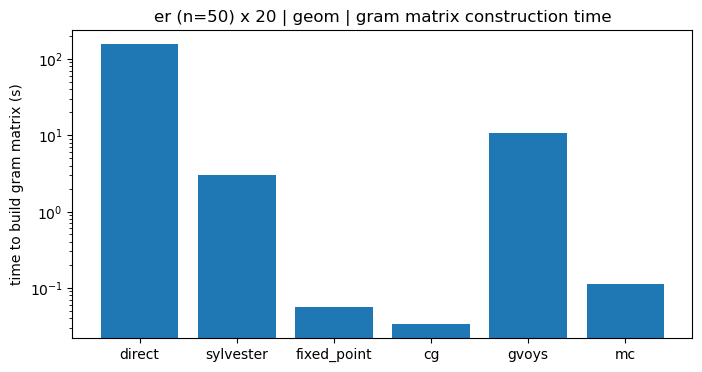

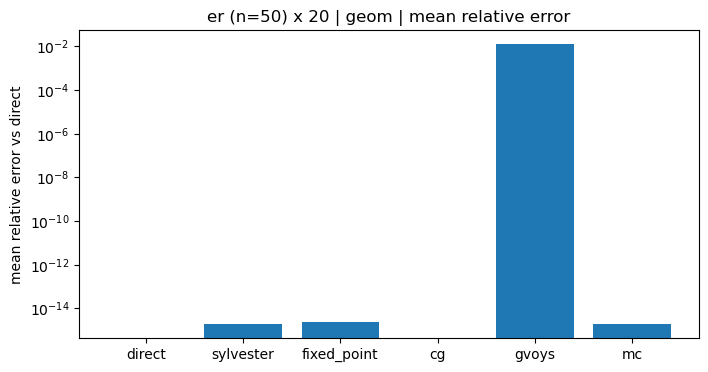

In [24]:
n_graphs = 20
n_nodes = 50
kind = "geom"
lmbd = 0.01
n_samples_mc = 10 * n_nodes
n_samples_gvoys = 10 * n_nodes
seed = 42
name = f"er (n={n_nodes}) x {n_graphs}"
dataset = [graph_generator(n=n_nodes, kind="er", seed=i) for i in range(n_graphs)]
mu_func = mu_func_gen(kind, lmbd=lmbd)

results_geom = bench(
    dataset=dataset,
    name=name,
    kind=kind,
    mu_func=mu_func,
    n_graphs=n_graphs,
    n_samples_mc=n_samples_mc,
    n_samples_gvoys=n_samples_gvoys,
    seed=seed,
)

print_benchmark_summary(results_geom, name=name, kind=kind, n_graphs=n_graphs)
plot_benchmark_results(results_geom, name=name, kind=kind)

In [25]:
def print_scaling_bench(results):
    print(
        f"scaling benchmark | kind={results['kind']} | lambda={results['lmbd']} | "
        f"pairs_per_size={results['n_pairs']}"
    )

    for i, n_nodes in enumerate(results["sizes"]):
        print(
            f"n={n_nodes} | n_samples_mc={results['n_samples_mc'][i]} | "
            f"n_samples_gvoys={results['n_samples_gvoys'][i]}"
        )
        for m in results["methods"]:
            print(
                f"  {m}: time={results['mean_time'][m][i]:.4e}s, "
                f"mean_rel={results['mean_rel_error'][m][i]:.4e}"
            )


def plot_scaling_bench(results):
    sizes = results["sizes"]
    methods = results["methods"]
    plt.figure(figsize=(10, 5))
    for m in methods:
        plt.plot(sizes, np.maximum(results["mean_time"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean time per pair")
    plt.title(f"geometric kernel | mean runtime over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    for m in methods:
        plt.plot(sizes, np.maximum(results["mean_rel_error"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean relative error vs direct")
    plt.title(f"geometric kernel | mean relative error over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

In [26]:
def bench_pair_geom(P1, P2, v1, v2, w1, w2, mu_func, n_samples_mc, n_samples_gvoys, seed):
    pair = {}

    t0 = time.perf_counter()
    val_direct = random_walk_kernel(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom")
    pair["direct"] = {"value": val_direct, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_syl = random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func=mu_func)
    pair["sylvester"] = {"value": val_syl, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_fp = random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    pair["fixed_point"] = {"value": val_fp, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_cg = random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    pair["cg"] = {"value": val_cg, "time": time.perf_counter() - t0}

    np.random.seed(seed)
    rnd.seed(seed)
    t0 = time.perf_counter()
    val_gvoys = approximate_graph_kernel_value_with_blocks(P1, P2, v1, v2, w1, w2, anchor_fraction=1.0, kind="geometric", 
        lambda_coeff=mu_func(1), p_halt=P_HALT, nb_random_walks=n_samples_gvoys, block_size=n_samples_gvoys)
    pair["gvoys"] = {"value": val_gvoys, "time": time.perf_counter() - t0}

    t0 = time.perf_counter()
    val_mc = random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom", n_samples=n_samples_mc, seed=seed)
    pair["mc"] = {"value": val_mc, "time": time.perf_counter() - t0}

    ref = pair["direct"]["value"]
    for m in pair:
        pair[m]["rel_err"] = abs(pair[m]["value"] - ref) / (abs(ref))
    return pair


def bench_scaling_geom(n_min_pow=4, n_max_pow=8, n_pairs=10, lmbd=0.01, samples_per_node=10, base_seed=42):
    mu_func = mu_func_gen("geom", lmbd=lmbd)
    methods = ["direct", "sylvester", "fixed_point", "cg", "gvoys", "mc"]
    sizes = [2 ** p for p in range(n_min_pow, n_max_pow + 1)]

    results = {
        "kind": "geom",
        "lmbd": lmbd,
        "n_pairs": n_pairs,
        "sizes": sizes,
        "methods": methods,
        "n_samples_mc": [],
        "n_samples_gvoys": [],
        "mean_time": {m: [] for m in methods},
        "mean_rel_error": {m: [] for m in methods},
    }

    for n_nodes in sizes:
        print("started size:", n_nodes)
        n_samples_mc = samples_per_node * n_nodes
        n_samples_gvoys = samples_per_node * n_nodes
        results["n_samples_mc"].append(n_samples_mc)
        results["n_samples_gvoys"].append(n_samples_gvoys)
        time_acc = {m: [] for m in methods}
        err_acc = {m: [] for m in methods}

        for pair_idx in range(n_pairs):
            seed = base_seed + 10_000 * n_nodes + pair_idx
            G1 = graph_generator(n=n_nodes, kind="er", seed=seed)
            G2 = graph_generator(n=n_nodes, kind="er", seed=seed + 1)
            P1 = normalized_adj_matrix(G1)
            P2 = normalized_adj_matrix(G2)
            v1 = uniform_dist(P1.shape[0])
            w1 = uniform_dist(P1.shape[0])
            v2 = uniform_dist(P2.shape[0])
            w2 = uniform_dist(P2.shape[0])
            pair = bench_pair_geom(P1, P2, v1, v2, w1, w2, mu_func=mu_func, n_samples_mc=n_samples_mc, n_samples_gvoys=n_samples_gvoys,seed=seed)
            for m in methods:
                time_acc[m].append(pair[m]["time"])
                err_acc[m].append(pair[m]["rel_err"])

        for m in methods:
            results["mean_time"][m].append(float(np.mean(time_acc[m])))
            results["mean_rel_error"][m].append(float(np.mean(err_acc[m])))

    return results


scaling_experiment_geom = bench_scaling_geom(n_min_pow=3, n_max_pow=7, n_pairs=3, lmbd=0.01, samples_per_node=10, base_seed=42)


started size: 8
started size: 16
started size: 32
started size: 64
started size: 128


scaling benchmark | kind=geom | lambda=0.01 | pairs_per_size=3
n=8 | n_samples_mc=80 | n_samples_gvoys=80
  direct: time=5.4950e-04s, mean_rel=0.0000e+00
  sylvester: time=8.0138e-04s, mean_rel=6.5947e-16
  fixed_point: time=1.1264e-04s, mean_rel=1.4655e-16
  cg: time=1.4000e-04s, mean_rel=1.4655e-16
  gvoys: time=2.9996e-02s, mean_rel=2.7208e-02
  mc: time=1.9017e-03s, mean_rel=1.4655e-16
n=16 | n_samples_mc=160 | n_samples_gvoys=160
  direct: time=3.0607e-03s, mean_rel=0.0000e+00
  sylvester: time=1.0969e-03s, mean_rel=6.5947e-16
  fixed_point: time=1.0278e-04s, mean_rel=1.4655e-16
  cg: time=1.6207e-04s, mean_rel=1.4655e-16
  gvoys: time=1.0166e-01s, mean_rel=1.1700e-02
  mc: time=3.7694e-03s, mean_rel=1.4655e-16
n=32 | n_samples_mc=320 | n_samples_gvoys=320
  direct: time=4.6368e-02s, mean_rel=0.0000e+00
  sylvester: time=3.0505e-03s, mean_rel=5.8620e-16
  fixed_point: time=1.5803e-04s, mean_rel=2.1982e-16
  cg: time=1.8424e-04s, mean_rel=2.1982e-16
  gvoys: time=4.1759e-01s, mean_

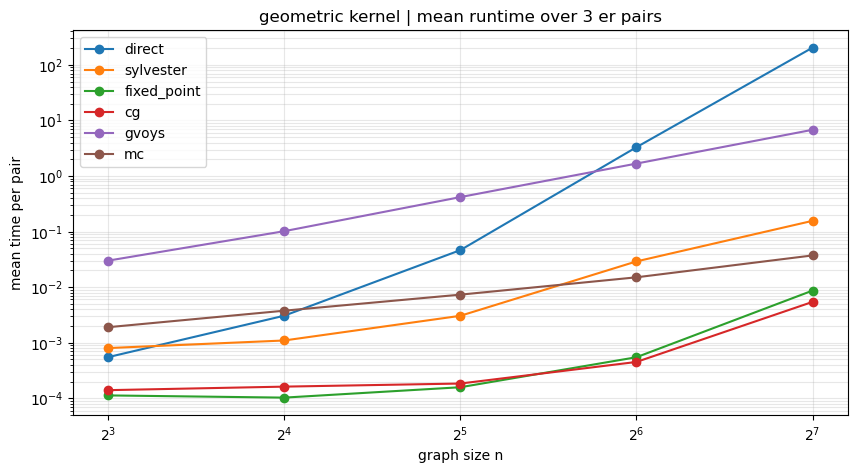

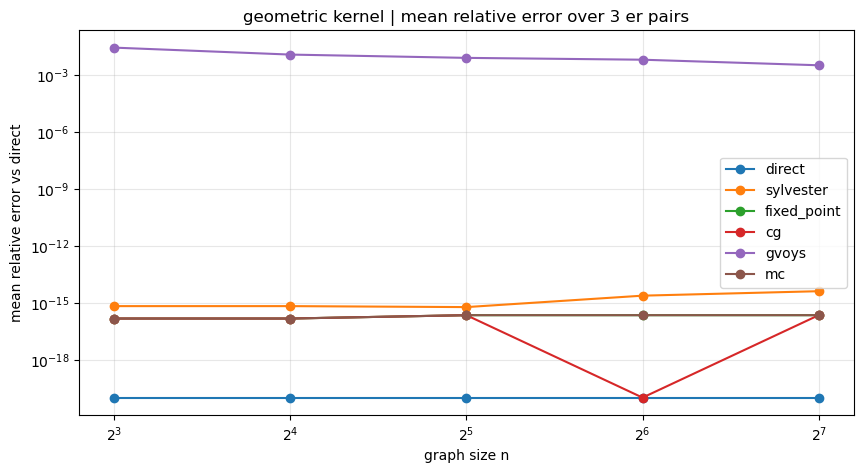

In [28]:
print_scaling_bench(scaling_experiment_geom)
plot_scaling_bench(scaling_experiment_geom)

In [36]:
def bench_pair_time_geom(P1, P2, v1, v2, w1, w2, mu_func, n_samples_mc, n_samples_gvoys, seed):
    times = {}

    t0 = time.perf_counter()
    random_walk_kernel_sylvester(P1, P2, v1, v2, w1, w2, mu_func=mu_func)
    times["sylvester"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_fixed_point(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    times["fixed_point"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_cg(P1, P2, v1, v2, w1, w2, mu_func=mu_func, eps=1e-30, max_iter=1000)
    times["cg"] = time.perf_counter() - t0

    np.random.seed(seed)
    rnd.seed(seed)
    t0 = time.perf_counter()
    approximate_graph_kernel_value_with_blocks(
        P1,
        P2,
        v1,
        v2,
        w1,
        w2,
        anchor_fraction=1.0,
        kind="geometric",
        lambda_coeff=mu_func(1),
        p_halt=P_HALT,
        nb_random_walks=n_samples_gvoys,
        block_size=n_samples_gvoys,
    )
    times["gvoys"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_walk_kernel_mc(P1, P2, v1, v2, w1, w2, mu_func=mu_func, kind="geom", n_samples=n_samples_mc, seed=seed)
    times["mc"] = time.perf_counter() - t0

    return times


def bench_scaling_time_geom(n_min_pow=3, n_max_pow=7, n_pairs=3, lmbd=0.01, samples_per_node=10, min_samples=100, base_seed=42):
    mu_func = mu_func_gen("geom", lmbd=lmbd)
    methods = ["sylvester", "fixed_point", "cg", "gvoys", "mc"]
    sizes = [2 ** p for p in range(n_min_pow, n_max_pow + 1)]

    results = {
        "kind": "geom",
        "lmbd": lmbd,
        "n_pairs": n_pairs,
        "sizes": sizes,
        "methods": methods,
        "n_samples_mc": [],
        "n_samples_gvoys": [],
        "mean_time": {m: [] for m in methods},
    }

    for n_nodes in sizes:
        print("size:", n_nodes)
        n_samples = max(min_samples, samples_per_node * n_nodes)
        n_samples_mc = n_samples
        n_samples_gvoys = n_samples

        results["n_samples_mc"].append(n_samples_mc)
        results["n_samples_gvoys"].append(n_samples_gvoys)

        time_acc = {m: [] for m in methods}

        for pair_idx in range(n_pairs):
            seed = base_seed + 10_000 * n_nodes + pair_idx
            G1 = graph_generator(n=n_nodes, kind="er", seed=seed)
            G2 = graph_generator(n=n_nodes, kind="er", seed=seed + 1)

            P1 = normalized_adj_matrix(G1)
            P2 = normalized_adj_matrix(G2)
            v1 = uniform_dist(P1.shape[0])
            w1 = uniform_dist(P1.shape[0])
            v2 = uniform_dist(P2.shape[0])
            w2 = uniform_dist(P2.shape[0])

            pair_times = bench_pair_time_geom(
                P1,
                P2,
                v1,
                v2,
                w1,
                w2,
                mu_func=mu_func,
                n_samples_mc=n_samples_mc,
                n_samples_gvoys=n_samples_gvoys,
                seed=seed,
            )

            for m in methods:
                time_acc[m].append(pair_times[m])

        for m in methods:
            results["mean_time"][m].append(float(np.mean(time_acc[m])))

    return results


def print_scaling_time_bench(results):
    print(
        f"scaling time benchmark | kind={results['kind']} | lambda={results['lmbd']} | "
        f"pairs_per_size={results['n_pairs']}"
    )

    for i, n_nodes in enumerate(results["sizes"]):
        print(
            f"n={n_nodes} | n_samples_mc={results['n_samples_mc'][i]} | "
            f"n_samples_gvoys={results['n_samples_gvoys'][i]}"
        )
        for m in results["methods"]:
            print(f"  {m}: time={results['mean_time'][m][i]:.4e}s")


def plot_scaling_time_bench(results):
    sizes = results["sizes"]

    plt.figure(figsize=(10, 5))
    for m in results["methods"]:
        plt.plot(sizes, np.maximum(results["mean_time"][m], 1e-20), marker="o", label=m)
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("graph size n")
    plt.ylabel("mean time per pair")
    plt.title(f"geometric kernel (no direct) | mean runtime over {results['n_pairs']} er pairs")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()


scaling_experiment_geom_time = bench_scaling_time_geom(
    n_min_pow=3,
    n_max_pow=9,
    n_pairs=3,
    lmbd=0.01,
    samples_per_node=10,
    min_samples=100,
    base_seed=42,
)

size: 8
size: 16
size: 32
size: 64
size: 128
size: 256
size: 512


: 

In [ ]:
print_scaling_time_bench(scaling_experiment_geom_time)
plot_scaling_time_bench(scaling_experiment_geom_time)

### Labeled